You need two different data subsets for your two goals:

1. Geographic Cluster Data: Use only latitude and longitude.

2. Temporal Cluster Data: Use hour, day_of_week (numeric), and month.

3. Crucial: Always use your scaled data (from scaler.pkl) for K-Means and Hierarchical clustering, as they rely on Euclidean distance.

Dataset Shape: (479440, 75)
Sample Shape: (50000, 75)


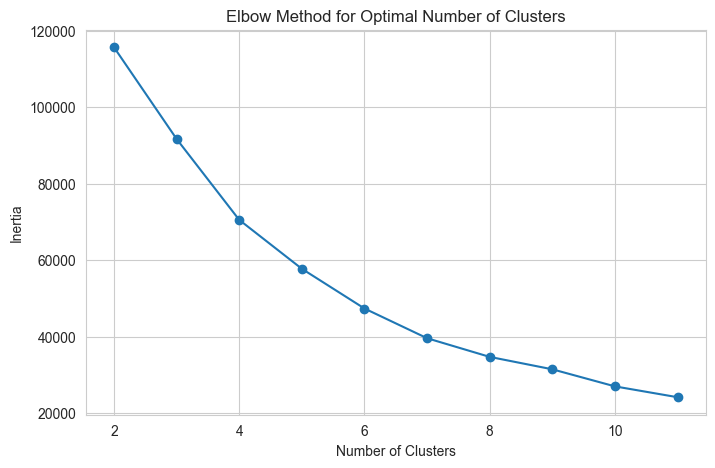

KMeans clustering completed


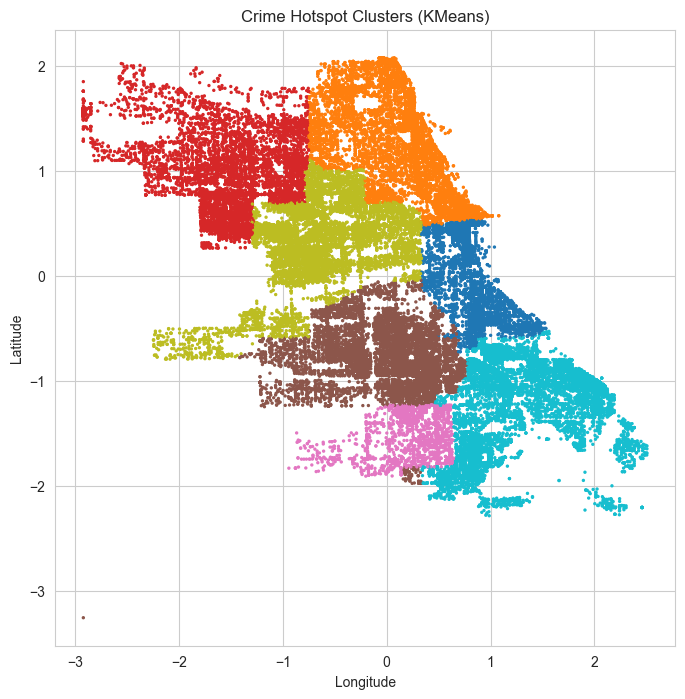

Silhouette Score: 0.40612163247317207
Davies-Bouldin Index: 0.8094526874255281
DBSCAN clustering completed


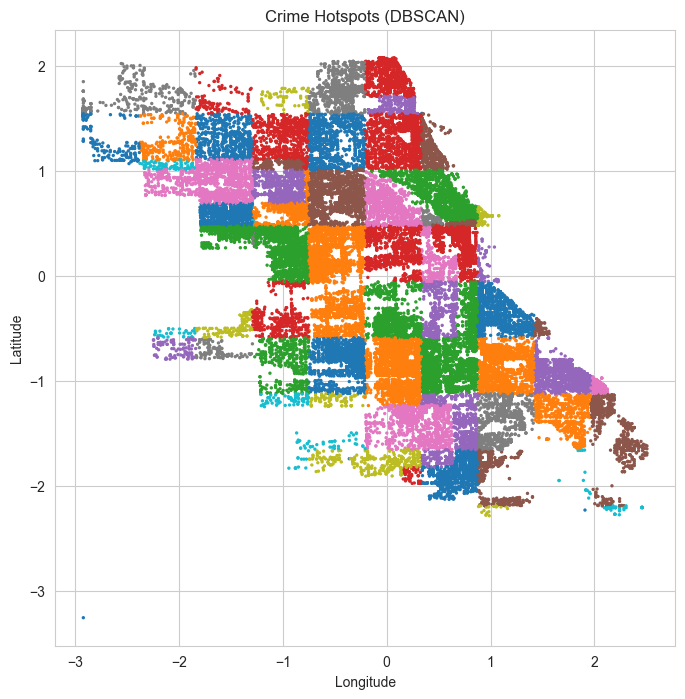

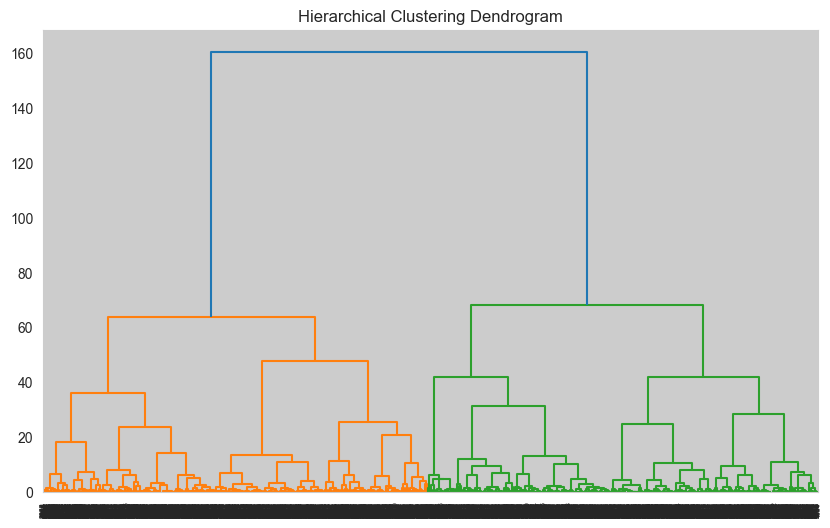

Temporal clustering completed


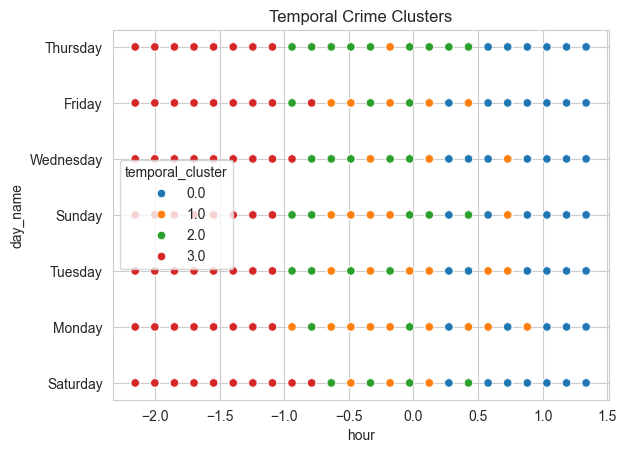

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")

df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\feature_data\feature_dataset.csv")

print("Dataset Shape:", df.shape)

# Sampling (to speed up clustering algorithms)
# ------------------------------------------------------------

sample_df = df.sample(50000, random_state=42)

print("Sample Shape:", sample_df.shape)

# Geographic Feature Selection

geo_features = sample_df[
    [
        "latitude",
        "longitude",
        "lat_bin",
        "lon_bin",
        "district_cluster"
    ]
]

# Elbow Method (Find optimal cluster count)

inertia = []

k_range = range(2,12)

for k in k_range:

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    model.fit(geo_features)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# KMeans Clustering
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)

sample_df["geo_cluster_kmeans"] = kmeans.fit_predict(geo_features)

print("KMeans clustering completed")

# Visualize KMeans Hotspots
# ------------------------------------------------------------

plt.figure(figsize=(8,8))

plt.scatter(
    sample_df["longitude"],
    sample_df["latitude"],
    c=sample_df["geo_cluster_kmeans"],
    cmap="tab10",
    s=2
)

plt.title("Crime Hotspot Clusters (KMeans)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# Clustering Evaluation
# ------------------------------------------------------------

sil_score = silhouette_score(geo_features, sample_df["geo_cluster_kmeans"])

print("Silhouette Score:", sil_score)

db_index = davies_bouldin_score(geo_features, sample_df["geo_cluster_kmeans"])

print("Davies-Bouldin Index:", db_index)

# DBSCAN Clustering
# ------------------------------------------------------------

dbscan = DBSCAN(eps=0.5, min_samples=10)

sample_df["geo_cluster_dbscan"] = dbscan.fit_predict(geo_features)

print("DBSCAN clustering completed")

# Visualize DBSCAN Clusters
# ------------------------------------------------------------

plt.figure(figsize=(8,8))

plt.scatter(
    sample_df["longitude"],
    sample_df["latitude"],
    c=sample_df["geo_cluster_dbscan"],
    cmap="tab10",
    s=2
)

plt.title("Crime Hotspots (DBSCAN)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# Hierarchical Clustering
# ------------------------------------------------------------

hier_sample = geo_features.sample(5000)

linked = linkage(hier_sample, method="ward")

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

# Temporal Feature Selection
# ------------------------------------------------------------

temporal_features = sample_df[
    [
        "hour",'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter','day_name_Friday', 'day_name_Monday',
       'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday',
       'day_name_Tuesday', 'day_name_Wednesday'

    ]
]

# Temporal KMeans Clustering
# ------------------------------------------------------------

kmeans_temporal = KMeans(n_clusters=4, random_state=42)

sample_df["temporal_cluster"] = kmeans_temporal.fit_predict(temporal_features)

print("Temporal clustering completed")

# Visualize Temporal Clusters
# ------------------------------------------------------------

sns.scatterplot(
    x=sample_df["hour"],
    y=df["day_name"],
    hue=sample_df["temporal_cluster"],
    palette="tab10"
)

plt.title("Temporal Crime Clusters")

plt.show()

In [2]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("PatrolIQ_Clustering")

with mlflow.start_run():

    # -----------------------------
    # Parameters
    # -----------------------------
    kmeans_k = 7
    dbscan_eps = 0.5
    dbscan_min_samples = 10

    mlflow.log_param("kmeans_clusters", kmeans_k)
    mlflow.log_param("dbscan_eps", dbscan_eps)
    mlflow.log_param("dbscan_min_samples", dbscan_min_samples)
    mlflow.log_param("sample_size", 50000)

    # -----------------------------
    # KMeans Metrics
    # -----------------------------
    sil_score = silhouette_score(geo_features, sample_df["geo_cluster_kmeans"])
    db_index = davies_bouldin_score(geo_features, sample_df["geo_cluster_kmeans"])

    print("Silhouette:", sil_score)
    print("DB Index:", db_index)

    mlflow.log_metric("kmeans_silhouette", sil_score)
    mlflow.log_metric("kmeans_db_index", db_index)

    # -----------------------------
    # DBSCAN Metrics (optional safe check)
    # -----------------------------
    mask = sample_df["geo_cluster_dbscan"] != -1

    if len(set(sample_df["geo_cluster_dbscan"][mask])) > 1:
        dbscan_sil = silhouette_score(
            geo_features[mask],
            sample_df["geo_cluster_dbscan"][mask]
        )
        mlflow.log_metric("dbscan_silhouette", dbscan_sil)

    # -----------------------------
    # Temporal Metrics
    # -----------------------------
    temp_sil = silhouette_score(
        temporal_features,
        sample_df["temporal_cluster"]
    )

    mlflow.log_metric("temporal_silhouette", temp_sil)

    print("✅ MLflow tracking completed")

2026/03/25 21:09:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/25 21:09:24 INFO mlflow.store.db.utils: Updating database tables
2026/03/25 21:09:26 INFO mlflow.tracking.fluent: Experiment with name 'PatrolIQ_Clustering' does not exist. Creating a new experiment.


Silhouette: 0.40612163247317207
DB Index: 0.8094526874255281
✅ MLflow tracking completed
